<center> <h1 style="background-color:firebrick; color:white" >House Price</h1> 

<center><img
src="https://smallcaps.com.au/wp-content/uploads/2020/07/Property-market-fall-Australia-COVID-19-2020.jpg" style="width:90%;height:40%;">
</center>
    
<br>    
    
<div class="list-group" id="list-tab" role="tablist">
  <h3 class="list-group-item list-group-item-action active" style="background-color:firebrick; color:white" data-toggle="list"  role="tab" aria-controls="home">Notebook Content!</h3>  
  <a class="list-group-item list-group-item-action" data-toggle="list" href="#libraries" role="tab" aria-controls="profile" style="color:firebrick">Import Libraries<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">1</span></a>
  <a id="section2" class="list-group-item list-group-item-action" data-toggle="list" href="#functions" role="tab" aria-controls="messages" style="color:firebrick">Functions<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">2</span></a>
 <a id="section2" class="list-group-item list-group-item-action" data-toggle="list" href="#load" role="tab" aria-controls="messages" style="color:firebrick">Load Data<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">3</span></a>
 <a class="list-group-item list-group-item-action"  data-toggle="list" href="#missing" role="tab" aria-controls="settings" style="color:firebrick">Missing Value<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">4</span></a>
 <a class="list-group-item list-group-item-action"  data-toggle="list" href="#datatypes" role="tab" aria-controls="settings" style="color:firebrick">Data Types<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">5</span></a>
    <a class="list-group-item list-group-item-action"  data-toggle="list" href="#ordinal" role="tab" aria-controls="settings" style="color:firebrick">Ordinal Variables<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">6</span></a>
  <a class="list-group-item list-group-item-action" data-toggle="list" href="#catbutcar" role="tab" aria-controls="settings" style="color:firebrick">Categorical But Cardinality High<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">7</span></a> 
 <a class="list-group-item list-group-item-action" data-toggle="list" href="#time" role="tab" aria-controls="settings" style="color:firebrick">Time Related Features<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">8</span></a> <a class="list-group-item list-group-item-action" data-toggle="list" href="#numbutcat" role="tab" aria-controls="settings" style="color:firebrick">Numerical But Categorical<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">9</span></a>    
    <a class="list-group-item list-group-item-action" data-toggle="list" href="#numeric" role="tab" aria-controls="settings" style="color:firebrick">Numeric Variables<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">10</span></a> 
    <a class="list-group-item list-group-item-action" data-toggle="list" href="#categoric" role="tab" aria-controls="settings" style="color:firebrick">Categoric Variables<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">11</span></a> 
    <a class="list-group-item list-group-item-action" data-toggle="list" href="#finaldata" role="tab" aria-controls="settings" style="color:firebrick">Final Data<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">12</span></a> 
    <a class="list-group-item list-group-item-action" data-toggle="list" href="#lgbm" role="tab" aria-controls="settings" style="color:firebrick">Light GBM<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">13</span></a> 
    <a class="list-group-item list-group-item-action" data-toggle="list" href="#error" role="tab" aria-controls="settings" style="color:firebrick">Error Analysis<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">14</span></a>     
    <a class="list-group-item list-group-item-action" data-toggle="list" href="#rs" role="tab" aria-controls="settings" style="color:firebrick">Randomized Search CV<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">15</span></a> 
    <a class="list-group-item list-group-item-action" data-toggle="list" href="#final" role="tab" aria-controls="settings" style="color:firebrick">Final Model & Submission<span class="badge badge-primary badge-pill" style="background-color:orangered; color:white">16</span></a> 

<a id='libraries'></a>
<h1 style="color:firebrick" >1. PACKAGES</h1>

In [1]:
# Base
# -----------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
# -----------------------------------
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

# Models 
# -----------------------------------
import lightgbm as lgb

# Metrics & Evaluation
# -----------------------------------
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_squared_log_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

<a id='functions'></a>
<h1 style="color:firebrick" >2. FUNCTIONS</h1>

In [2]:
# Grab Column Names
def grab_col_names(dataframe, cat_th=10, car_th=20, show_date = False):

    date_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "datetime64[ns]"]

    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O" and dataframe[col].dtypes != "datetime64[ns]"]

    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'date_cols: {len(date_cols)}')
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    # cat_cols + num_cols + cat_but_car = değişken sayısı.
    # num_but_cat cat_cols'un içerisinde zaten.
    # dolayısıyla tüm şu 3 liste ile tüm değişkenler seçilmiş olacaktır: cat_cols + num_cols + cat_but_car
    # num_but_cat sadece raporlama için verilmiştir.

    if show_date == True:
        return date_cols, cat_cols, cat_but_car, num_cols, num_but_cat
    else:
        return cat_cols, cat_but_car, num_cols, num_but_cat
    
    
# Rare Encoder
def rare_encoder(dataframe, rare_perc):
    temp_df = dataframe.copy()

    rare_columns = [col for col in temp_df.columns if temp_df[col].nunique() >= 5 and temp_df[col].nunique() <= 20
                    and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]

    for var in rare_columns:
        tmp = temp_df[var].value_counts() / len(temp_df)
        rare_labels = tmp[tmp < rare_perc].index
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), 'Rare', temp_df[var])

        return temp_df
      
# Missing Value
def missing_values(data, plot = False, target = "SalePrice"):
    
    mst = pd.DataFrame({"Num_Missing":data.isnull().sum(), "Missing_Ratio":data.isnull().sum() / data.shape[0]}).sort_values("Num_Missing", ascending = False)
    mst["DataTypes"] = data[mst.index].dtypes.values
    mst = mst[mst.Num_Missing > 0].reset_index().rename({"index":"Feature"}, axis = 1)
    mst = mst[mst.Feature != target]
    
    print("Number of Variables include Missing Values:", mst.shape[0], "\n")
    
    if mst[mst.Missing_Ratio >= 1.0].shape[0] > 0:  
        print("Full Missing Variables:",mst[mst.Missing_Ratio >= 1.0].Feature.tolist())
        data.drop(mst[mst.Missing_Ratio >= 1.0].Feature.tolist(), axis = 1, inplace = True)

        print("Full missing variables are deleted!", "\n")

    if plot:
        plt.figure(figsize = (25, 8))    
        p = sns.barplot(mst.Feature, mst.Missing_Ratio)
        for rotate in p.get_xticklabels():
            rotate.set_rotation(90)
        plt.show()    
            
    print(mst, "\n")        
    
    
# Ordinal Variables
def ordinal(serie, category):
    numeric = np.arange(1, len(category)+1, 1)
    zip_iterator = zip(category, numeric)
    mapping = dict(zip_iterator)
    serie = serie.map(mapping)
    return serie

def transform_ordinal(data, ordinal_vars, category):
    
    for i in ordinal_vars:
        data[i] = ordinal(data[i], category = category)
        
# Categorical Variables & Target
def cat_analyzer(dataframe, variable, target):   
    print(variable)
    print(pd.DataFrame({
        "COUNT":dataframe[variable].value_counts(),
        "RATIO":dataframe[variable].value_counts() / len(dataframe),
        "TARGET_COUNT":dataframe.groupby(variable)[target].count(),
        "TARGET_MEAN":dataframe.groupby(variable)[target].mean(),
        "TARGET_MEDIAN":dataframe.groupby(variable)[target].median(),
        "TARGET_STD":dataframe.groupby(variable)[target].std()}), end="\n\n\n")
        
# One Hot Encoder        
def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe
    
# Label Encoder
def label_encoder(dataframe, binary_col):
    labelencoder = preprocessing.LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe
  
# CART FEATURE GENERATOR
def cart_feature_gen(model_type, dataframe, X, y, suffix = None):
    # Model Type
    if model_type == "reg":
        from sklearn.tree import DecisionTreeRegressor
        model = DecisionTreeRegressor()
    elif model_type == "class":
        from sklearn.tree import DecisionTreeClassifier
        model = DecisionTreeClassifier()
    else:
        print("Give a model type! model_type argument should be equal to 'reg' or 'class'")
        return None
    
    # Remove NaN
    temp = dataframe[[X,y]].dropna()
    
    # Fit a tree
    rules = model.fit(temp[[X]], temp[y])
  
    # First Decision Rule
    print(X)
    print("Threshold:", rules.tree_.threshold[0])
    print("Range:", "["+str(dataframe[X].min())+" - "+str(dataframe[X].max()) +"]", "\n")
    if suffix == None:
        new_colname = "DTREE_"+X.upper()
    else:
        new_colname = "DTREE_"+suffix+"_"+X.upper()
    dataframe[new_colname] = np.where(dataframe[X] <= rules.tree_.threshold[0], 1, 0)   

<a id='load'></a>
<h1 style="color:firebrick" >3. DATA</h1>

In [3]:
# Import
train = pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("../input/house-prices-advanced-regression-techniques/test.csv")

# Bind rows
df = train.append(test)

# Num of dtypes
cat_cols, cat_but_car, num_cols, num_but_cat = grab_col_names(df, car_th=10)

# Dimensions
print(df.shape, train.shape, test.shape)

df.head()

Observations: 2919
Variables: 81
date_cols: 0
cat_cols: 50
num_cols: 28
cat_but_car: 3
num_but_cat: 10
(2919, 81) (1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706.00,Unf,0.00,150.00,856.00,GasA,Ex,Y,SBrkr,856,854,0,1710,1.00,0.00,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2.00,548.00,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.00
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.00,Unf,0.00,284.00,1262.00,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.00,1.00,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2.00,460.00,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.00
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.00,Unf,0.00,434.00,920.00,GasA,Ex,Y,SBrkr,920,866,0,1786,1.00,0.00,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2.00,608.00,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.00
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216.00,Unf,0.00,540.00,756.00,GasA,Gd,Y,SBrkr,961,756,0,1717,1.00,0.00,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3.00,642.00,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.00
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655.00,Unf,0.00,490.00,1145.00,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.00,0.00,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3.00,836.00,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.00


<a id='missing'></a>
<h1 style="color:firebrick" >4. MISSING VALUE</h1>

Number of Variables include Missing Values: 34 



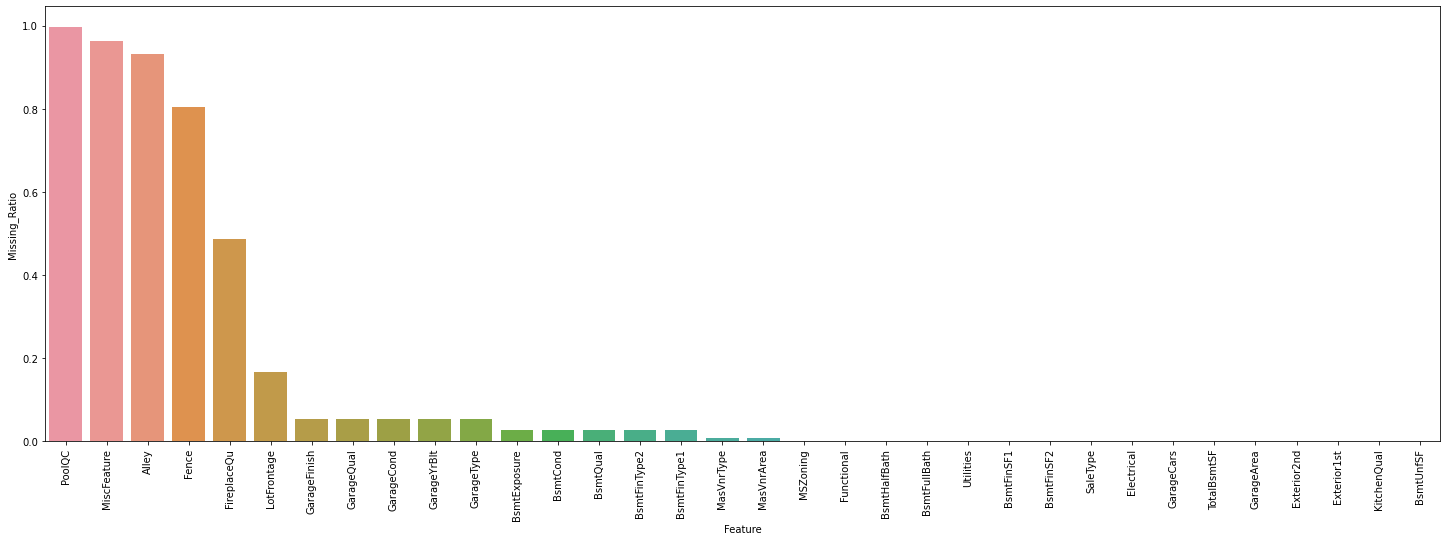

         Feature  Num_Missing  Missing_Ratio DataTypes
0         PoolQC         2909           1.00    object
1    MiscFeature         2814           0.96    object
2          Alley         2721           0.93    object
3          Fence         2348           0.80    object
5    FireplaceQu         1420           0.49    object
6    LotFrontage          486           0.17   float64
7   GarageFinish          159           0.05    object
8     GarageQual          159           0.05    object
9     GarageCond          159           0.05    object
10   GarageYrBlt          159           0.05   float64
11    GarageType          157           0.05    object
12  BsmtExposure           82           0.03    object
13      BsmtCond           82           0.03    object
14      BsmtQual           81           0.03    object
15  BsmtFinType2           80           0.03    object
16  BsmtFinType1           79           0.03    object
17    MasVnrType           24           0.01    object
18    MasV

In [4]:
# First investigation
missing_values(df, plot = True, target = "SalePrice")

In [5]:
# Some categorical variables includes None category as missing value.
cat_missing = ["Alley", 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1','BsmtFinType2','Fence', "MiscFeature",
               "FireplaceQu", "GarageFinish","GarageCond", "GarageQual", "GarageType", "MasVnrType"]

# Fill NA
for i in cat_missing:
    df[i] = df[i].fillna("None")

# Fill NA
for i in cat_missing:
    df[i] = np.where(df[i].isnull() == True, "None", df[i])

In [6]:
# Second investigation    
missing_values(df, plot = False, target = "SalePrice")

Number of Variables include Missing Values: 20 

         Feature  Num_Missing  Missing_Ratio DataTypes
0         PoolQC         2909           1.00    object
2    LotFrontage          486           0.17   float64
3    GarageYrBlt          159           0.05   float64
4     MasVnrArea           23           0.01   float64
5       MSZoning            4           0.00    object
6      Utilities            2           0.00    object
7   BsmtHalfBath            2           0.00   float64
8     Functional            2           0.00    object
9   BsmtFullBath            2           0.00   float64
10   Exterior1st            1           0.00    object
11    BsmtFinSF2            1           0.00   float64
12      SaleType            1           0.00    object
13    GarageCars            1           0.00   float64
14   Exterior2nd            1           0.00    object
15    BsmtFinSF1            1           0.00   float64
16    GarageArea            1           0.00   float64
17   KitchenQual

<a id='datatypes'></a>
<h1 style="color:firebrick" >5. DATA TYPES</h1>

In [7]:
ordinal_vars = [
    "LotShape", "OverallQual", "OverallCond", "ExterQual", "ExterCond", "BsmtQual",
    "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual", "Functional",
    "FireplaceQu", "GarageQual", "GarageCond", "Fence", "Electrical", "LandSlope"
]

cat_cols, cat_but_car, num_cols, num_but_cat = grab_col_names(df.drop(ordinal_vars, axis = 1), car_th=10)

Observations: 2919
Variables: 62
date_cols: 0
cat_cols: 32
num_cols: 27
cat_but_car: 3
num_but_cat: 9


<a id='ordinal'></a>
<h1 style="color:firebrick" >6. ORDINAL VARIABLES</h1>

In [8]:
df.ExterQual.unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [9]:
# Same Categories        
transform_ordinal(
    df, 
    ordinal_vars = ["ExterQual", "ExterCond", "HeatingQC","KitchenQual"],
    category = ["Po", "Fa", "TA", "Gd" ,"Ex"]
)

transform_ordinal(
    df, 
    ordinal_vars = ["BsmtQual", "BsmtCond", "FireplaceQu","GarageCond", "GarageQual"],
    category = ["None", "Po", "Fa", "TA", "Gd","Ex"]
)

transform_ordinal(
    df, 
    ordinal_vars = ["BsmtFinType1", "BsmtFinType2"],
    category = ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ","GLQ"]
)

# Different
df["LotShape"] = ordinal(df["LotShape"], category = ["IR3", "IR2", "IR1","Reg"])
df["BsmtExposure"] = ordinal(df["BsmtExposure"], category = ["None", "No", "Mn", "Av","Gd"])
df["Functional"] = ordinal(df["Functional"], category = ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1","Typ"])
df["Fence"] = ordinal(df["Fence"], category = ["None", "MnWw", "GdWo", "MnPrv","GdPrv"])
df["Electrical"] = ordinal(df["Electrical"], category = ['SBrkr', 'FuseA', 'FuseF', 'FuseP', 'Mix'])
df["LandSlope"] =  ordinal(df["LandSlope"], category = ['Gtl', 'Mod', "Sev"])
print("Ordinal transformation completed!")  

Ordinal transformation completed!


In [10]:
# Run Cat Analyzer for Ordinal Variables
for i in ordinal_vars:
    cat_analyzer(df, i, "SalePrice") 

LotShape
   COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
1     16   0.01            10    216036.50      203570.00    82540.33
2     76   0.03            41    239833.37      221000.00    99669.43
3    968   0.33           484    206101.67      189000.00    85858.49
4   1859   0.64           925    164754.82      146000.00    69673.43


OverallQual
    COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
1       4   0.00             2     50150.00       50150.00    15344.22
2      13   0.00             3     51770.33       60000.00    14254.20
3      40   0.01            20     87473.75       86250.00    24688.57
4     226   0.08           116    108420.66      108000.00    29022.00
5     825   0.28           397    133523.35      133000.00    27107.33
6     731   0.25           374    161603.03      160000.00    36090.18
7     600   0.21           319    207716.42      200141.00    44466.26
8     342   0.12           168    274735.54      269750.00 

In [11]:
# Create Ordinal Scores
df["TotalQual"] = df[["OverallQual", "OverallCond", "ExterQual", "ExterCond", "BsmtCond", "BsmtFinType1", 
                      "BsmtFinType2", "HeatingQC", "KitchenQual", "Functional", "FireplaceQu", "GarageQual", "GarageCond", "Fence"]].sum(axis = 1)
df["BsmtQual"] = df[["BsmtCond", "BsmtFinType1", "BsmtFinType2"]].sum(axis = 1)
df["TotalGarageQual"] = df[["GarageQual", "GarageCond"]].sum(axis = 1)
df["Overall"] = df[["OverallQual", "OverallCond"]].sum(axis = 1)
df["Exter"] = df[["ExterQual", "ExterCond"]].sum(axis = 1)
df["ExtraQual"] = df[["Fence", "FireplaceQu", "Functional", "HeatingQC"]].sum(axis = 1)
df["Qual"] = df[["OverallQual", "ExterQual", "GarageQual", "Fence", "BsmtFinType1", "BsmtFinType2", "KitchenQual", "FireplaceQu"]].sum(axis = 1)
df["Cond"] = df[["OverallCond", "ExterCond", "GarageCond", "BsmtCond", "HeatingQC", "Functional"]].sum(axis = 1)
df["CLUSTER_TOTALQUAL"] = pd.qcut(df.TotalQual, q=10, labels=range(1,11))
df.groupby("CLUSTER_TOTALQUAL").SalePrice.agg({"count", "mean", "median", "std"})


# Create Ratio
df["RATIO_OVERALLQ"] = df.OverallQual / df.TotalQual
df["RATIO_OVERALLC"] = df.OverallCond / df.TotalQual
df["RATIO_EXTERQ"] = df.ExterQual / df.TotalQual
df["RATIO_EXTERC"] = df.ExterCond / df.TotalQual
df["RATIO_BSMTC"] = df.BsmtCond / df.TotalQual
df["RATIO_BSMTFT1"] = df.BsmtFinType1 / df.TotalQual
df["RATIO_BSMTFT2"] = df.BsmtFinType2 / df.TotalQual
df["RATIO_HEATINGQC"] = df.HeatingQC / df.TotalQual
df["RATIO_KITCHENQ"] = df.KitchenQual / df.TotalQual
df["RATIO_FUNCTIONAL"] = df.Functional / df.TotalQual
df["RATIO_FIREPLACEQ"] = df.FireplaceQu / df.TotalQual
df["RATIO_GARAGEQ"] = df.GarageQual / df.TotalQual
df["RATIO_GARAGEC"] = df.GarageCond / df.TotalQual
df["RATIO_FENCE"] = df.Fence / df.TotalQual

# Grade
df["OverallGrade"] = (df["OverallQual"]+1) * (df["OverallCond"]+1)
df["BsmtGrade"] = (df["BsmtQual"]+1) * (df["BsmtCond"]+1)
df["GarageGrade"] = (df["GarageQual"]+1) * (df["GarageCond"]+1)
df["ExterGrade"] = (df["ExterQual"]+1) * (df["ExterCond"]+1)
df["KitchenGrade"] = (df["KitchenAbvGr"]+1) * (df["KitchenQual"]+1)
df["FireplaceGrade"] = (df["Fireplaces"]+1) * (df["FireplaceQu"]+1)
df["DifGrade"] = (df.HeatingQC+1)*(df.Functional+1)*(df.Fence+1)*(df.Electrical+1)

# Unite some categories by looking summary stats
df["LotShape"] = np.where(df.LotShape == 1, 2, df["LotShape"])
df["OverallQual"] = np.where(df.OverallQual.isin([1, 2, 3]), 3, df["OverallQual"])
df["OverallCond"] = np.where(df.OverallCond.isin([1, 2, 3]), 3, df["OverallCond"])
df["ExterCond"] = np.where(df.ExterCond.isin([1, 2]), 2, df["ExterCond"])
df["ExterCond"] = np.where(df.ExterCond.isin([5]), 4, df["ExterCond"])
df["BsmtQual"] = np.where(df.BsmtQual.isin([1,2,3]), 3, df["BsmtQual"])
df["BsmtCond"] = np.where(df.BsmtCond.isin([1,2]), 2, df["BsmtCond"])
df["HeatingQC"] = np.where(df.HeatingQC.isin([1]), 2, df["HeatingQC"])
df["Functional"] = np.where(df.Functional.isin([2]), 3, df["Functional"])
df["Functional"] = np.where(df.Functional.isin([6]), 7, df["Functional"])
df["FireplaceQu"] = np.where(df.FireplaceQu.isin([1]), 2, df["FireplaceQu"])
df["GarageQual"] = np.where(df.GarageQual.isin([2]), 3, df["GarageQual"])
df["GarageQual"] = np.where(df.GarageQual.isin([5,6]), 4, df["GarageQual"])
df["GarageCond"] = np.where(df.GarageCond.isin([2]), 3, df["GarageCond"])
df["GarageCond"] = np.where(df.GarageCond.isin([5,6]), 4, df["GarageCond"])
df["Fence"] = np.where(df.Fence.isin([2]), 3, df["Fence"])
df["Electrical"] = np.where(df.Electrical.isin([4,5]), 3, df["Electrical"])

<a id='catbutcar'></a>
<h1 style="color:firebrick" >7. CATEGORICAL BUT CARDINALITY HIGH</h1>

In [12]:
# Show variables
cat_but_car

['Neighborhood', 'Exterior1st', 'Exterior2nd']

In [13]:
# Some categories are same
df["Exterior1st"] = np.where((df["Exterior1st"].isin(["Brk Cmn", "BrkComm"])) | (df["Exterior2nd"].isin(["Brk Cmn", "BrkComm"])), "BrkComm",df["Exterior1st"])
df["Exterior2nd"] = np.where((df["Exterior1st"].isin(["Brk Cmn", "BrkComm"])) | (df["Exterior2nd"].isin(["Brk Cmn", "BrkComm"])), "BrkComm",df["Exterior2nd"])
df["Exterior1st"] = np.where((df["Exterior1st"].isin(["CemntBd", "CmentBd"])) | (df["Exterior2nd"].isin(["CemntBd", "CmentBd"])), "CmentBd",df["Exterior1st"])
df["Exterior2nd"] = np.where((df["Exterior1st"].isin(["CemntBd", "CmentBd"])) | (df["Exterior2nd"].isin(["CemntBd", "CmentBd"])), "CmentBd",df["Exterior2nd"])
df["Exterior1st"] = np.where((df["Exterior1st"].isin(["Wd Shng", "WdShing"])) | (df["Exterior2nd"].isin(["Wd Shng", "WdShing"])), "WdShing",df["Exterior1st"])
df["Exterior2nd"] = np.where((df["Exterior1st"].isin(["Wd Shng", "WdShing"])) | (df["Exterior2nd"].isin(["Wd Shng", "WdShing"])), "WdShing",df["Exterior2nd"])


In [14]:
# Cat Analyzer
for i in cat_but_car:
    cat_analyzer(df, i, "SalePrice")
  
  
# Rare Encoder for Exterior
for i in ['Exterior1st', 'Exterior2nd']:
    df[i] = rare_encoder(df[[i]], rare_perc=0.01)
  

Neighborhood
         COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
Blmngtn     28   0.01            17    194870.88      191000.00    30393.23
Blueste     10   0.00             2    137500.00      137500.00    19091.88
BrDale      30   0.01            16    104493.75      106000.00    14330.18
BrkSide    108   0.04            58    124834.05      124300.00    40348.69
ClearCr     44   0.02            28    212565.43      200250.00    50231.54
CollgCr    267   0.09           150    197965.77      197200.00    51403.67
Crawfor    103   0.04            51    210624.73      200624.00    68866.40
Edwards    194   0.07           100    128219.70      121750.00    43208.62
Gilbert    165   0.06            79    192854.51      181000.00    35986.78
IDOTRR      93   0.03            37    100123.78      103000.00    33376.71
MeadowV     37   0.01            17     98576.47       88000.00    23491.05
Mitchel    114   0.04            49    156270.12      153500.00    36486.63

In [15]:
# Cat Analyzer
for i in cat_but_car:
    cat_analyzer(df, i, "SalePrice")

Neighborhood
         COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
Blmngtn     28   0.01            17    194870.88      191000.00    30393.23
Blueste     10   0.00             2    137500.00      137500.00    19091.88
BrDale      30   0.01            16    104493.75      106000.00    14330.18
BrkSide    108   0.04            58    124834.05      124300.00    40348.69
ClearCr     44   0.02            28    212565.43      200250.00    50231.54
CollgCr    267   0.09           150    197965.77      197200.00    51403.67
Crawfor    103   0.04            51    210624.73      200624.00    68866.40
Edwards    194   0.07           100    128219.70      121750.00    43208.62
Gilbert    165   0.06            79    192854.51      181000.00    35986.78
IDOTRR      93   0.03            37    100123.78      103000.00    33376.71
MeadowV     37   0.01            17     98576.47       88000.00    23491.05
Mitchel    114   0.04            49    156270.12      153500.00    36486.63

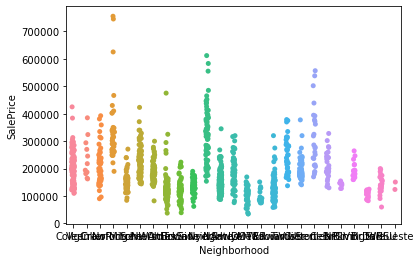

In [16]:
# Neighborhood 
sns.stripplot(x='Neighborhood', y='SalePrice', data=df, jitter=True)
#sns.despine()
plt.show()

In [17]:


# Create Cluster
ngb =df.groupby("Neighborhood").SalePrice.mean().reset_index()
ngb["CLUSTER_NEIGHBORHOOD"] = pd.cut(df.groupby("Neighborhood").SalePrice.mean().values, 4, labels = range(1,5))
ngb.groupby("CLUSTER_NEIGHBORHOOD").SalePrice.agg({"count", "mean", "max"})
df = pd.merge(df, ngb.drop(["SalePrice"], axis = 1), how = "left", on = "Neighborhood")
df.groupby("CLUSTER_NEIGHBORHOOD").SalePrice.agg({"count", "median", "mean", "max", "std"})
del ngb

In [18]:
# One Hot Encoder for CAT BUT CAR
df = one_hot_encoder(df, cat_but_car, drop_first=True)

<a id='time'></a>
<h1 style="color:firebrick" >8. TIME RELATED FEATURES</h1>

GarageYrBlt
MIN: 1895.0 	 MAX: 2207.0 

MoSold
MIN: 1 	 MAX: 12 

YrSold
MIN: 2006 	 MAX: 2010 

YearBuilt
MIN: 1872 	 MAX: 2010 

YearRemodAdd
MIN: 1950 	 MAX: 2010 



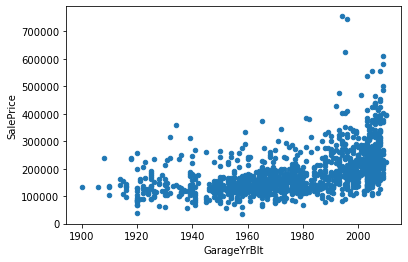

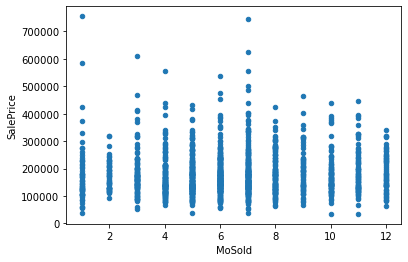

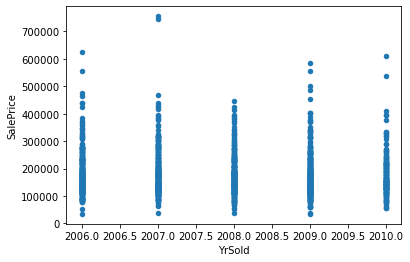

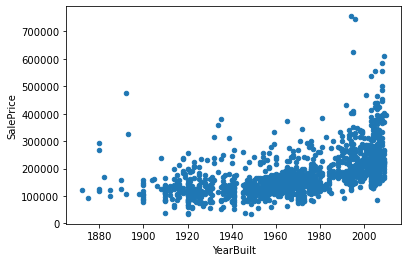

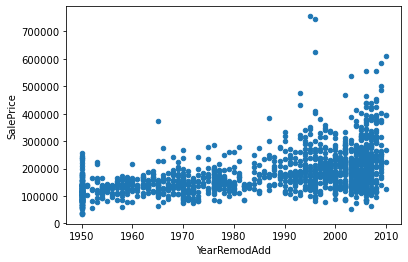

In [19]:
time_cols = ["GarageYrBlt", "MoSold", "YrSold", "YearBuilt", "YearRemodAdd"]

for i in time_cols:
    print(i)
    print("MIN:", df[i].min(), "\t", "MAX:", df[i].max(), "\n")

for i in time_cols:
    df.plot.scatter(x = i, y ="SalePrice")
    plt.show()

In [20]:
# Some issues
# same as construction date if no remodeling or additions
df.YearRemodAdd = np.where(df.YearRemodAdd.isnull(), df.YearBuilt, df.YearRemodAdd)
df.YearRemodAdd = np.where(df.YearBuilt > df.YearRemodAdd, df.YearBuilt, df.YearRemodAdd)
df.YrSold = np.where(df.YearBuilt > df.YrSold, df.YearBuilt, df.YrSold)
df.YrSold = np.where(df.YearRemodAdd > df.YrSold, df.YearRemodAdd, df.YrSold)

df["GarageYrBlt"] = np.where(df.GarageYrBlt == 2207, 2007, df.GarageYrBlt)

# Age Features
df["HOUSEAGE"] = df.YrSold - df.YearBuilt
df["REMODAGE"] = df.YrSold - df.YearRemodAdd
df["GARAGEAGE"] = df.YrSold - df.GarageYrBlt
df["REMODBLTAGE"] = df.YearRemodAdd - df.YearBuilt
df["GARAGEBLTAGE"] = df.GarageYrBlt - df.YearBuilt


df["REMODELED"] = np.where(df.YearBuilt == df.YearRemodAdd, 0 ,1)
df["ISNEWHOUSE"] = np.where(df.YearBuilt == df.YrSold, 1 ,0)

df.drop(["MoSold", "YrSold"],axis = 1, inplace = True)

# Create Cluster
df["CLUSTER_YEARBUILT"] = np.where(df.YearBuilt <= 1940, 1, 2)
df["CLUSTER_YEARBUILT"] = np.where(df.YearBuilt >= 1980, 3, df["CLUSTER_YEARBUILT"])
df["CLUSTER_GARAGEBUILT"] = np.where(df.GarageYrBlt <= 1940, 1, 2)
df["CLUSTER_GARAGEBUILT"] = np.where(df.GarageYrBlt >= 1980, 3, df["CLUSTER_GARAGEBUILT"])
df["CLUSTER_YEARREMODADD"] = np.where(df.YearRemodAdd >= 1980, 2, 1)

In [21]:
# Apply CART Feature Generator
time_cols = ["GarageYrBlt", "YearBuilt", "YearRemodAdd", "HOUSEAGE", "REMODAGE", "GARAGEAGE", "REMODBLTAGE", "GARAGEBLTAGE"]

for i in time_cols:
    cart_feature_gen(model_type="reg", dataframe=df, X=i, y="SalePrice", suffix = "TIME")

# Cat Analyzer for CART Features
for i in df.columns[df.columns.str.contains("DTREE_TIME")].tolist():
    cat_analyzer(df, i ,"SalePrice")

# Remove Years
df.drop(["GarageYrBlt", "YearBuilt", "YearRemodAdd"], axis = 1, inplace = True)

GarageYrBlt
Threshold: 1991.5
Range: [1895.0 - 2010.0] 

YearBuilt
Threshold: 1984.5
Range: [1872 - 2010] 

YearRemodAdd
Threshold: 1983.5
Range: [1950 - 2010] 

HOUSEAGE
Threshold: 21.5
Range: [0 - 136] 

REMODAGE
Threshold: 22.5
Range: [0 - 60] 

GARAGEAGE
Threshold: 19.5
Range: [0.0 - 114.0] 

REMODBLTAGE
Threshold: 1.5
Range: [0 - 127] 

GARAGEBLTAGE
Threshold: 1.5
Range: [-20.0 - 123.0] 

DTREE_TIME_GARAGEYRBLT
   COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
0   1313   0.45           654    217367.66      200000.00    93167.11
1   1606   0.55           806    151348.01      141000.00    49420.94


DTREE_TIME_YEARBUILT
   COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
0   1163   0.40           578    237018.66      215000.00    84308.55
1   1756   0.60           882    144158.91      137000.00    48772.90


DTREE_TIME_YEARREMODADD
   COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
0   1661   0.57           848    213323.4

<a id='numbutcat'></a>
<h1 style="color:firebrick" >9. NUMERICAL BUT CATEGORICAL</h1>

In [22]:
num_but_cat.remove("YrSold")
num_but_cat

['BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'Fireplaces',
 'GarageCars']

In [23]:
df.BsmtFullBath.value_counts()

0.00    1705
1.00    1172
2.00      38
3.00       2
Name: BsmtFullBath, dtype: int64

In [24]:
for i in num_but_cat:
    cat_analyzer(df, i ,"SalePrice")

BsmtFullBath
      COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
0.00   1705   0.58           856    165521.64      154150.00    68137.82
1.00   1172   0.40           588    202522.92      178800.00    88895.87
2.00     38   0.01            15    213063.07      188000.00    87308.20
3.00      2   0.00             1    179000.00      179000.00         nan


BsmtHalfBath
      COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
0.00   2742   0.94          1378    181230.33      163250.00    79303.22
1.00    171   0.06            80    176098.12      159000.00    82901.00
2.00      4   0.00             2    160850.50      160850.50    47164.73


FullBath
   COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
0     12   0.00             9    165200.89      145000.00   106083.81
1   1309   0.45           650    134751.44      132375.00    41565.08
2   1530   0.52           768    213009.83      196750.00    72446.81
3     64   0.02         

In [25]:
df["TOTALBATH"] = df.BsmtFullBath + df.BsmtHalfBath*0.5 + df.FullBath + df.HalfBath*0.5
df["TOTALFULLBATH"] = df.BsmtFullBath + df.FullBath 
df["TOTALHALFBATH"] = df.BsmtHalfBath + df.HalfBath
df["ROOMABVGR"] = df.BedroomAbvGr + df.KitchenAbvGr
df["RATIO_ROOMABVGR"] = df["ROOMABVGR"] / df.TotRmsAbvGrd

In [26]:
# Apply CART Feature Generator
for i in num_but_cat:
    cart_feature_gen(model_type="reg", dataframe=df, X=i, y="SalePrice", suffix = "NUMCAT")

# Cat Analyzer for CART Features
for i in df.columns[df.columns.str.contains("DTREE_NUMCAT")].tolist():
    cat_analyzer(df, i ,"SalePrice")

BsmtFullBath
Threshold: 0.5
Range: [0.0 - 3.0] 

BsmtHalfBath
Threshold: 0.5
Range: [0.0 - 2.0] 

FullBath
Threshold: 1.5
Range: [0 - 4] 

HalfBath
Threshold: 0.5
Range: [0 - 2] 

BedroomAbvGr
Threshold: 3.5
Range: [0 - 8] 

KitchenAbvGr
Threshold: 1.5
Range: [0 - 3] 

Fireplaces
Threshold: 0.5
Range: [0 - 4] 

GarageCars
Threshold: 2.5
Range: [0.0 - 5.0] 

DTREE_NUMCAT_BSMTFULLBATH
   COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
0   1214   0.42           604    202745.73      179100.00    88732.19
1   1705   0.58           856    165521.64      154150.00    68137.82


DTREE_NUMCAT_BSMTHALFBATH
   COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
0    177   0.06            82    175726.23      159000.00    82072.81
1   2742   0.94          1378    181230.33      163250.00    79303.22


DTREE_NUMCAT_FULLBATH
   COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
0   1598   0.55           801    218563.92      200000.00    82718.21
1 

In [27]:
df["BedroomAbvGr"] = np.where(df.BedroomAbvGr == 0, 1, df.BedroomAbvGr)
df["BedroomAbvGr"] = np.where(df.BedroomAbvGr > 4, 4, df.BedroomAbvGr)
df["BsmtFullBath"] = np.where(df.BsmtFullBath > 2, 2, df.BsmtFullBath)
df["Fireplaces"] = np.where(df.Fireplaces > 2, 2, df.Fireplaces)
df["FullBath"] = np.where(df.Fireplaces < 1, 1, df.FullBath)
df["FullBath"] = np.where(df.Fireplaces > 2, 3, df.FullBath)
df["GRG_CARS_AREA"] = df.GarageCars / df.GarageArea
df["GarageCars"] = np.where(df.GarageCars > 2, 3, df.GarageCars)
df.drop(["BsmtHalfBath", "KitchenAbvGr"], axis = 1, inplace = True) # We generated this by using cart feature gen

<a id='numeric'></a>
<h1 style="color:firebrick" >10. NUMERIC VARIABLES</h1>

In [28]:
for i in ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MoSold', "Id"]:
    num_cols.remove(i)
num_cols

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'TotRmsAbvGrd',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'SalePrice']

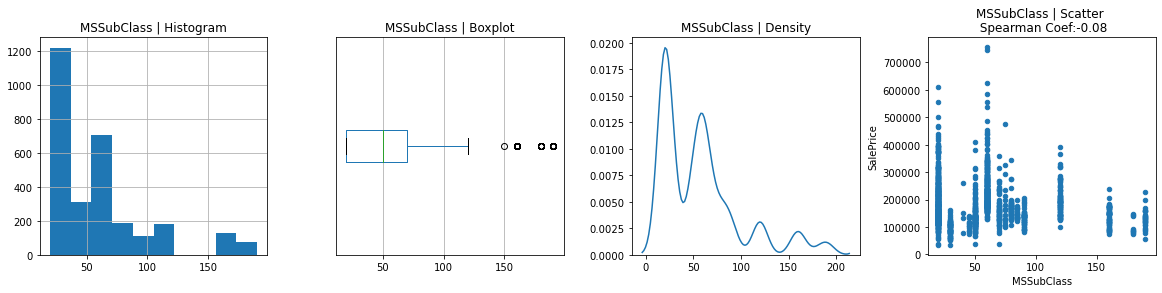

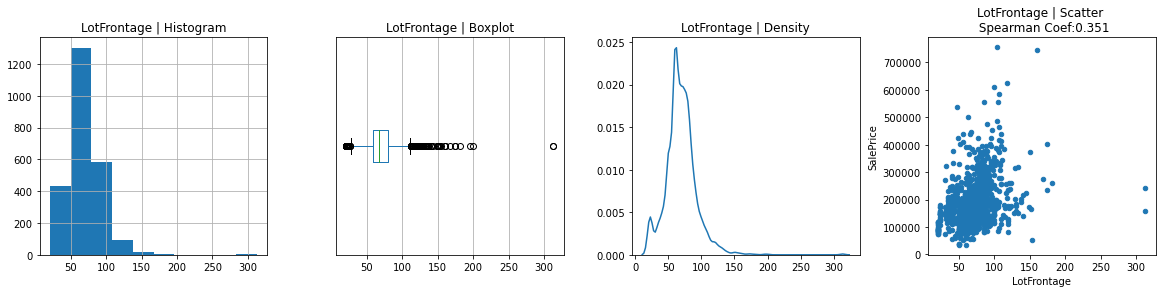

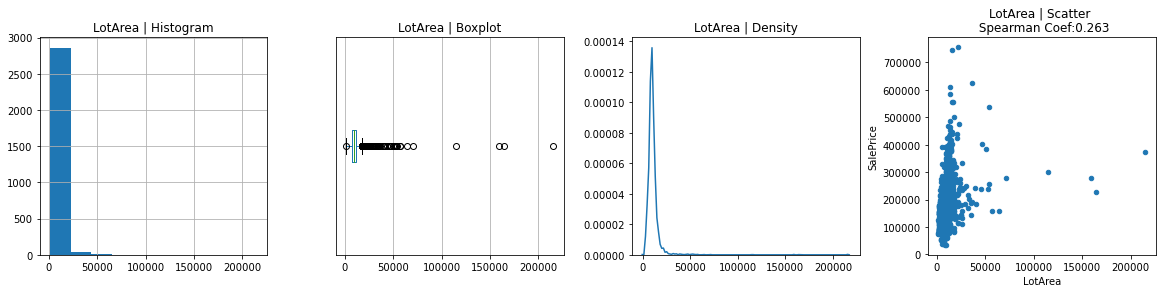

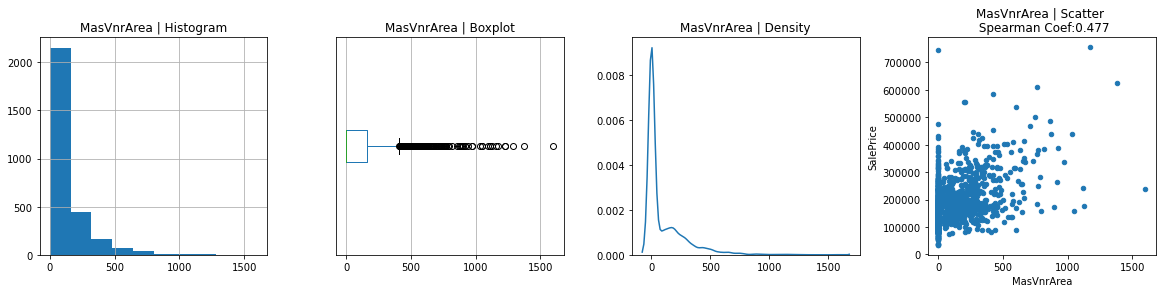

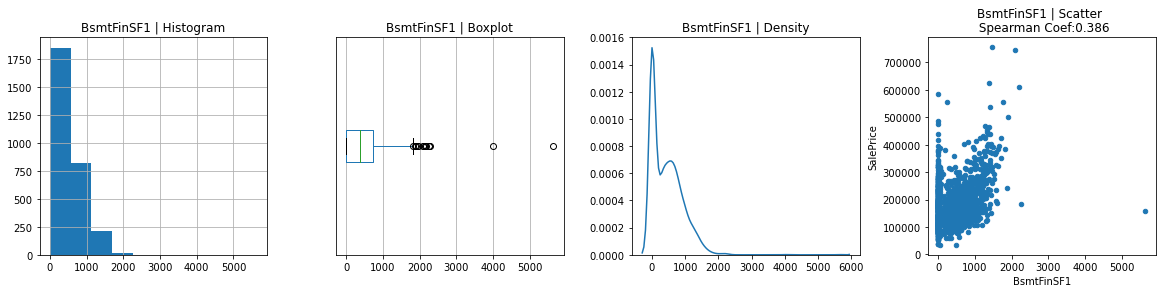

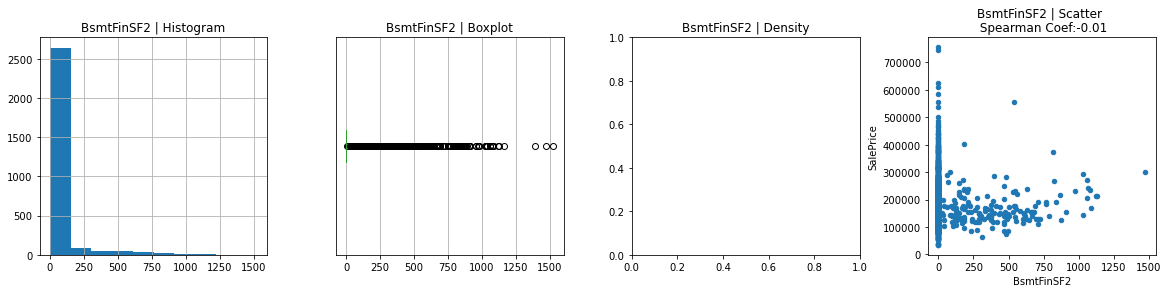

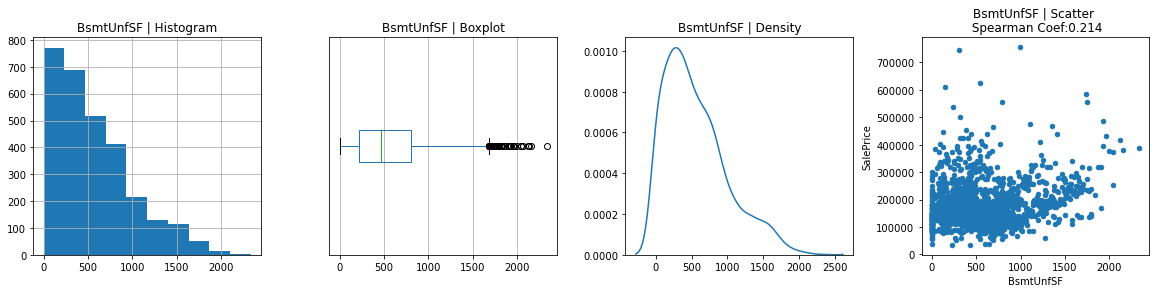

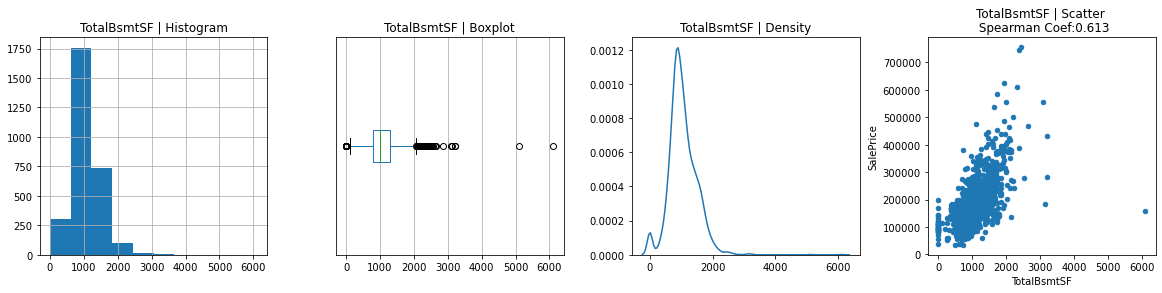

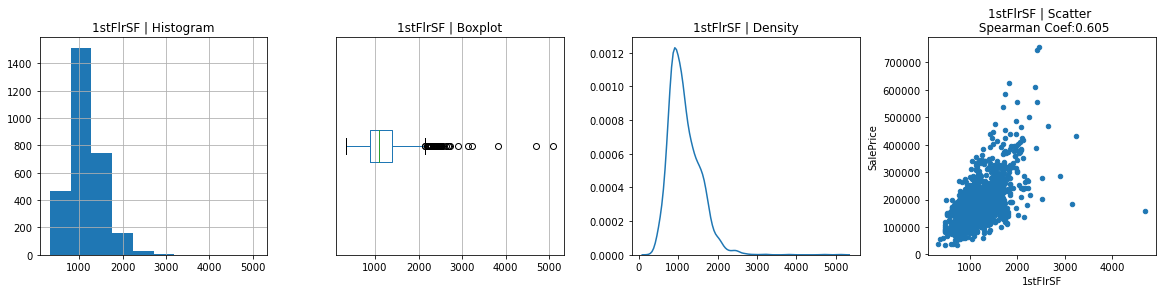

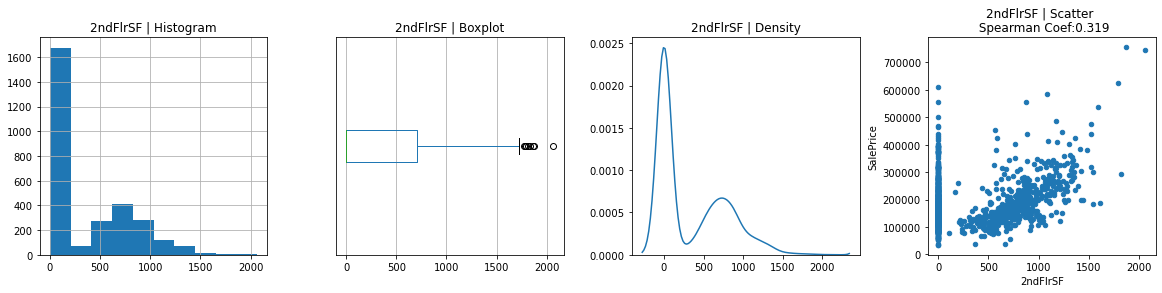

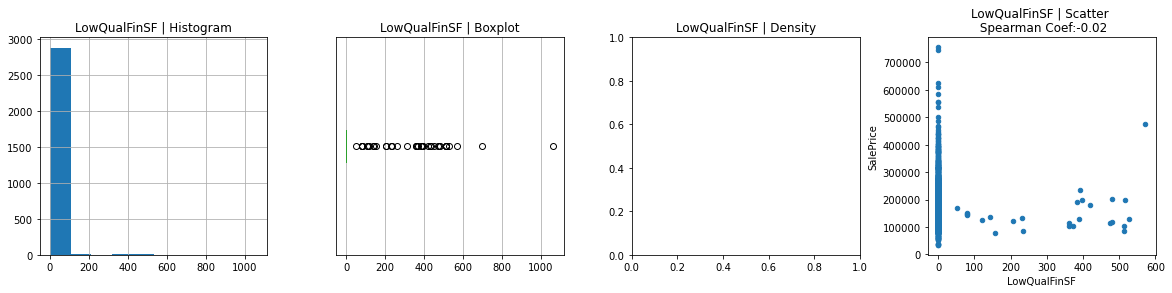

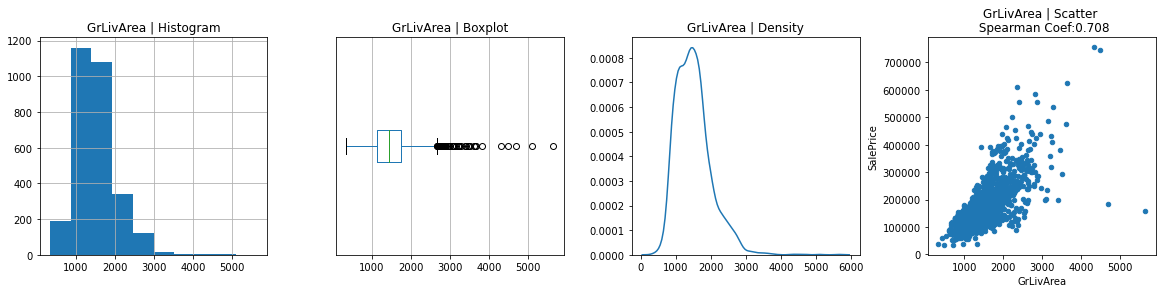

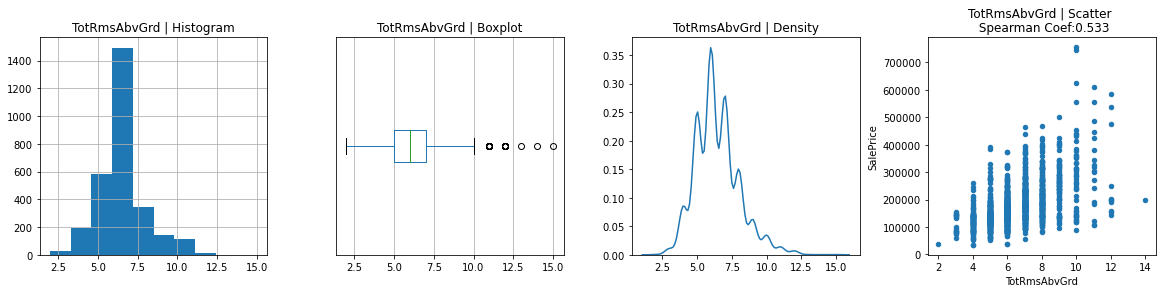

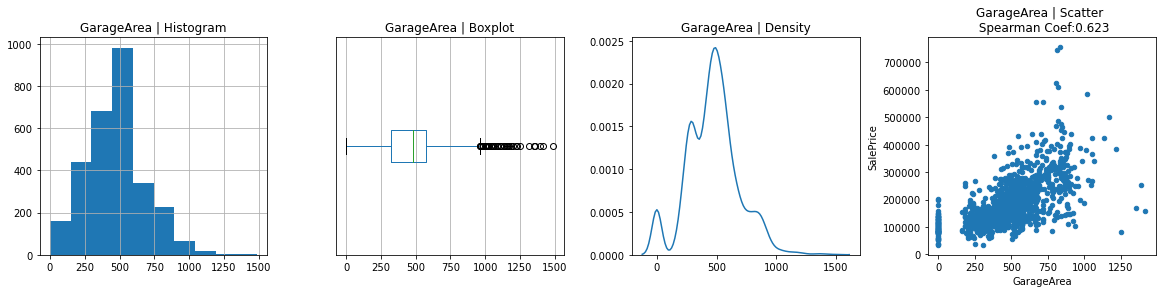

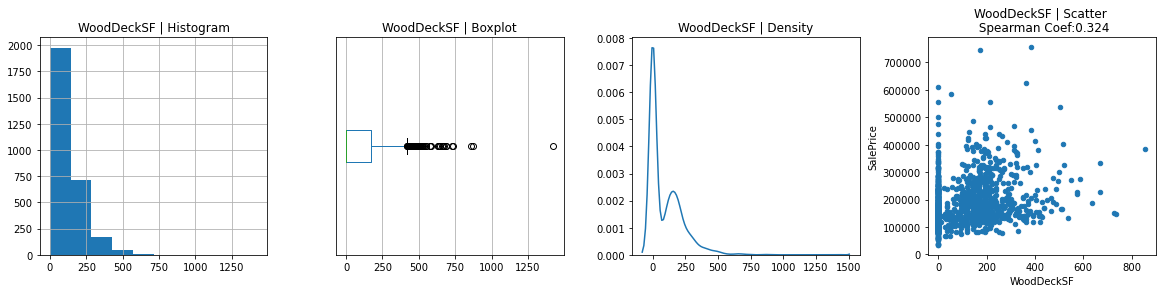

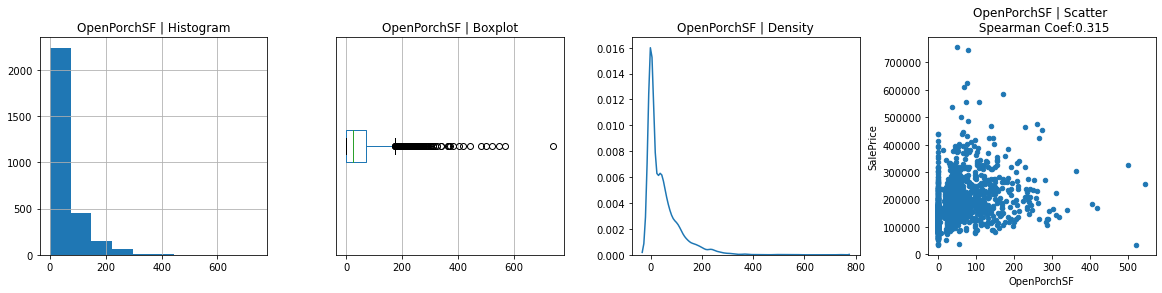

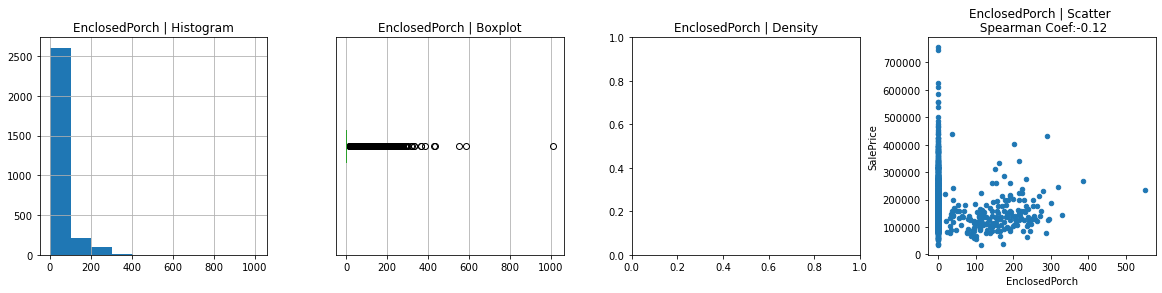

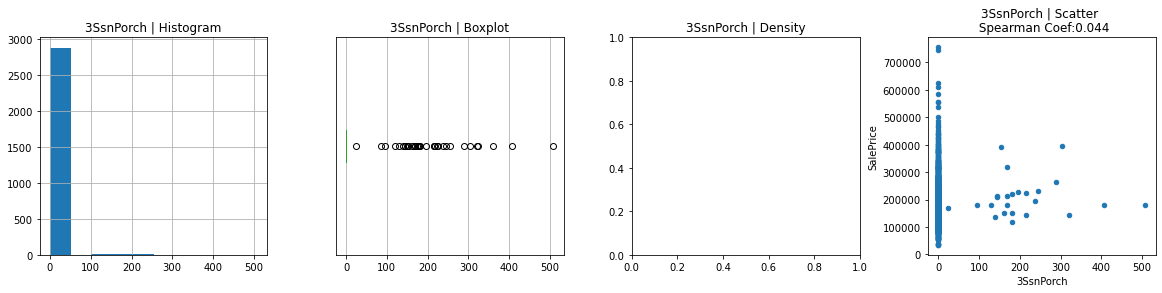

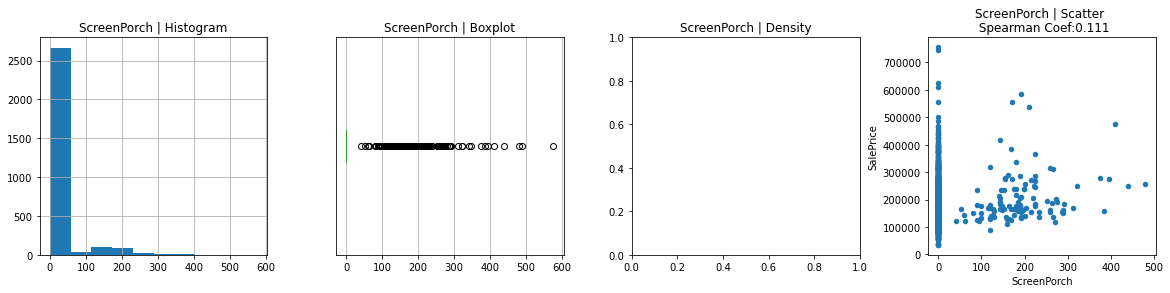

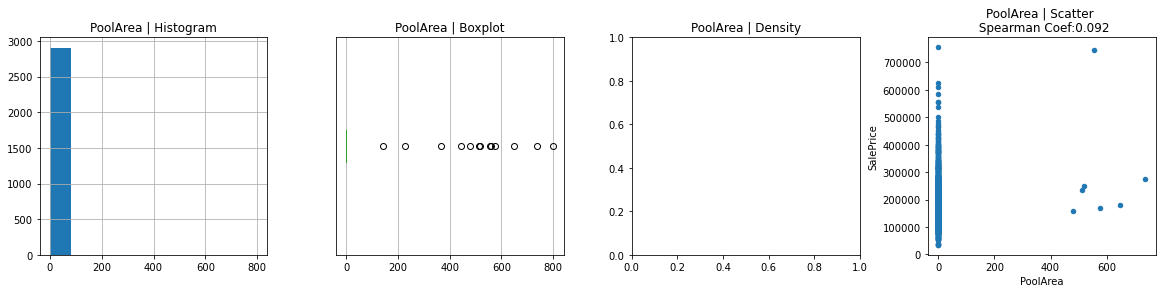

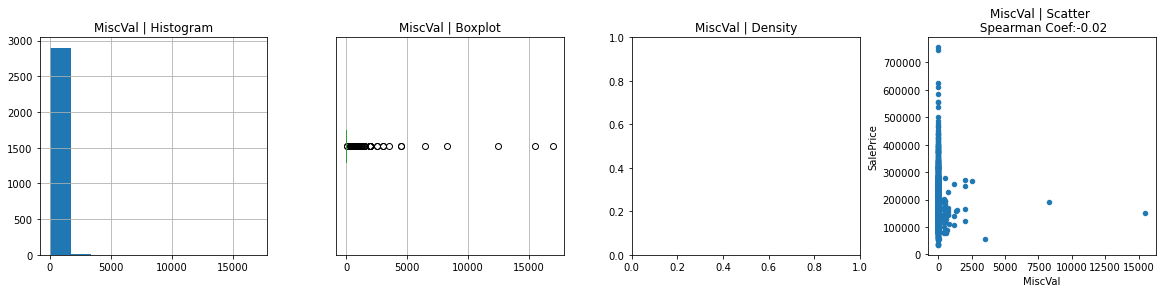

TypeError: sort_values() missing 1 required positional argument: 'by'

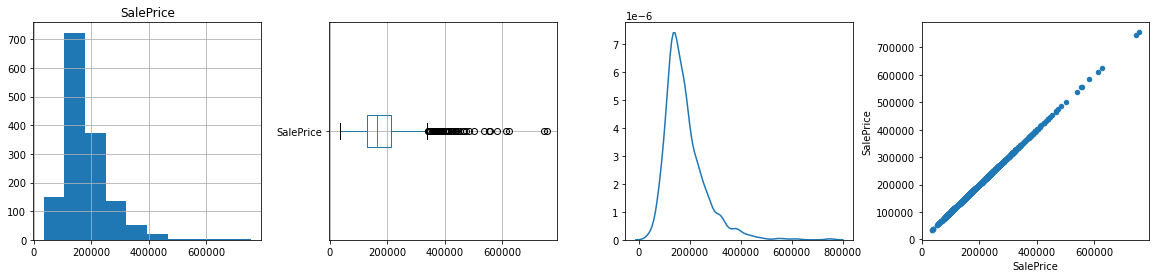

In [29]:
# Visuals
for i in num_cols:
    #if i == "SalePrice":
    #    return None
    fig, axes = plt.subplots(1, 4, figsize = (20,4))
    df.hist(str(i), bins = 10, ax=axes[0])
    df.boxplot(str(i),  ax=axes[1], vert=False);
    try: 
        sns.kdeplot(np.array(df[str(i)]),ax=axes[2])
    except: ValueError
    df.plot.scatter(x = i, y = "SalePrice", ax=axes[3])
    cortext = df[[i, "SalePrice"]].corr().SalePrice.sort_values()[0]
    axes[1].set_yticklabels([])
    axes[1].set_yticks([])
    axes[0].set_title(i + " | Histogram")
    axes[1].set_title(i + " | Boxplot")
    axes[2].set_title(i + " | Density")
    axes[3].set_title(i + " | Scatter \n Spearman Coef:" + str(cortext)[:5])
    plt.show()

In [30]:
# Correlation     
df[num_cols].corr("spearman").SalePrice.sort_values(ascending = False)[1:]

GrLivArea        0.73
GarageArea       0.65
TotalBsmtSF      0.60
1stFlrSF         0.58
TotRmsAbvGrd     0.53
OpenPorchSF      0.48
LotArea          0.46
MasVnrArea       0.42
LotFrontage      0.41
WoodDeckSF       0.35
BsmtFinSF1       0.30
2ndFlrSF         0.29
BsmtUnfSF        0.19
ScreenPorch      0.10
3SsnPorch        0.07
PoolArea         0.06
MSSubClass       0.01
BsmtFinSF2      -0.04
MiscVal         -0.06
LowQualFinSF    -0.07
EnclosedPorch   -0.22
Name: SalePrice, dtype: float64

In [31]:
# Floor
# --------------------------------------
df["TOTAL_FLRSF"] = df["1stFlrSF"] + df["2ndFlrSF"]
df["Floor"] = np.where((df["2ndFlrSF"] < 1), 1, 2)

# Basement
# --------------------------------------
# Total Finished Basement Area
df["TOTAL_BSMTFIN"] = df.BsmtFinSF1+df.BsmtFinSF2
df["RATIO_BSMTFIN"] = (df.TOTAL_BSMTFIN / df.TotalBsmtSF).fillna(0)
# Is there a basement?
df["BASEMENT"] = np.where(df.TotalBsmtSF < 1 , 0, 1)

# Basement Rooms
df["BsmtRoom"] = np.where((df.BsmtFinSF1 > 0) & (df.BsmtFinSF2 < 1), 1, np.nan)
df["BsmtRoom"] = np.where((df.BsmtFinSF1 < 1) & (df.BsmtFinSF2 > 0 ), 1, df["BsmtRoom"])
df["BsmtRoom"] = np.where((df.BsmtFinSF1 < 1) & (df.BsmtFinSF2 < 1 ), 0, df["BsmtRoom"])
df["BsmtRoom"] = np.where((df.BsmtFinSF1 > 0) & (df.BsmtFinSF2 > 0 ), 2, df["BsmtRoom"])


# Total House Area
df["TotalHouseArea"] = df.TOTAL_FLRSF + df.TotalBsmtSF
df["TotalSqFeet"] = df.GrLivArea + df.TotalBsmtSF


# Porch Area
# --------------------------------------
df["PorchArea"] = df.OpenPorchSF + df.EnclosedPorch + df.ScreenPorch + df["3SsnPorch"] + df.WoodDeckSF


# Lot 
# --------------------------------------
df["LotRatio"] = df.GrLivArea / df.LotArea
df["RatioArea"] = df.TotalHouseArea / df.LotArea
df["GarageLotRatio"] = df.GarageArea / df.LotArea

# Other
# --------------------------------------
# MasVnrArea
df["MasVnrRatio"] = df.MasVnrArea / df.TotalHouseArea
# LowQualFinSF
df["LowQualFinSFRatio"] = df.LowQualFinSF / df.TotalHouseArea

In [32]:
# Apply CART Feature Generator
num_cols.remove("MSSubClass")
num_cols.remove("SalePrice")

for i in num_cols:
    cart_feature_gen(model_type="reg", dataframe=df, X=i, y="SalePrice", suffix = "NUM")

# Cat Analyzer for CART Features
for i in df.columns[df.columns.str.contains("DTREE_NUM")].tolist():
    cat_analyzer(df, i ,"SalePrice")

LotFrontage
Threshold: 81.5
Range: [21.0 - 313.0] 

LotArea
Threshold: 10924.0
Range: [1300 - 215245] 

MasVnrArea
Threshold: 183.5
Range: [0.0 - 1600.0] 

BsmtFinSF1
Threshold: 1118.5
Range: [0.0 - 5644.0] 

BsmtFinSF2
Threshold: 805.5
Range: [0.0 - 1526.0] 

BsmtUnfSF
Threshold: 1105.5
Range: [0.0 - 2336.0] 

TotalBsmtSF
Threshold: 1443.0
Range: [0.0 - 6110.0] 

1stFlrSF
Threshold: 1443.0
Range: [334 - 5095] 

2ndFlrSF
Threshold: 1047.5
Range: [0 - 2065] 

LowQualFinSF
Threshold: 550.0
Range: [0 - 1064] 

GrLivArea
Threshold: 1488.0
Range: [334 - 5642] 

TotRmsAbvGrd
Threshold: 6.5
Range: [2 - 15] 

GarageArea
Threshold: 675.5
Range: [0.0 - 1488.0] 

WoodDeckSF
Threshold: 121.5
Range: [0 - 1424] 

OpenPorchSF
Threshold: 28.5
Range: [0 - 742] 

EnclosedPorch
Threshold: 19.5
Range: [0 - 1012] 

3SsnPorch
Threshold: 142.0
Range: [0 - 508] 

ScreenPorch
Threshold: 166.5
Range: [0 - 576] 

PoolArea
Threshold: 537.0
Range: [0 - 800] 

MiscVal
Threshold: 27.0
Range: [0 - 17000] 

DTREE_NUMC

<a id='categoric'></a>
<h1 style="color:firebrick" >11. CATEGORIC VARIABLES</h1>

In [33]:
df["HasMasVnrType"] = np.where(df.MasVnrType == "None", 0, 1)
df["BoughtOffPlan"] = np.where(df.SaleCondition == "Partial", 1, 0)

for i in ['BedroomAbvGr', 'BsmtFullBath', 'BsmtHalfBath', 'Fireplaces', 'FullBath', 'GarageCars', 'HalfBath', 'KitchenAbvGr', 'YrSold']:
    cat_cols.remove(i)
cat_cols = ["MSSubClass"]+cat_cols

In [34]:
for i in cat_cols:
    cat_analyzer(df, i, "SalePrice")

MSSubClass
     COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
20    1079   0.37           536    185224.81      159250.00    78782.19
30     139   0.05            69     95829.72       99900.00    24857.11
40       6   0.00             4    156125.00      142500.00    75747.80
45      18   0.01            12    108591.67      107500.00    20231.72
50     287   0.10           144    143302.97      132000.00    54851.98
60     575   0.20           299    239948.50      215200.00    86579.91
70     128   0.04            60    166772.42      156000.00    58206.55
75      23   0.01            16    192437.50      163500.00   100556.76
80     118   0.04            58    169736.55      166500.00    38197.81
85      48   0.02            20    147810.00      140750.00    19629.94
90     109   0.04            52    133541.08      135980.00    27833.25
120    182   0.06            87    200779.08      192000.00    58221.49
150      1   0.00             0          nan         

In [35]:
# Remove useless variables
rm = ["Street", "Utilities", "PoolQC", "MiscFeature", "Heating", "Condition2"]
df.drop(rm, axis = 1, inplace = True)
for i in rm:
    cat_cols.remove(i)
cat_cols

['MSSubClass',
 'MSZoning',
 'Alley',
 'LandContour',
 'LotConfig',
 'Condition1',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'MasVnrType',
 'Foundation',
 'CentralAir',
 'GarageType',
 'GarageFinish',
 'PavedDrive',
 'SaleType',
 'SaleCondition']

In [36]:
# Condition1
df["Condition1"] = np.where(df.Condition1.isin(["Artery", "Feedr"]), "Road", df.Condition1)
df["Condition1"] = np.where(df.Condition1.isin(["RRAe", "RRAn", "RRNe", "RRNn"]), "RR", df.Condition1)
df["Condition1"] = np.where(df.Condition1.isin(["PosA", "PosN"]), "Pos", df.Condition1)

In [37]:
# Rare Encoder
for i in ["MSSubClass", "Foundation", "HouseStyle", "RoofMatl", "RoofStyle", "SaleCondition", "SaleType"]:
    df[i] = rare_encoder(df[[i]], rare_perc=0.01)

# Cat Analyzer
for i in cat_cols:
    cat_analyzer(df, i, "SalePrice")

MSSubClass
      COUNT  RATIO  TARGET_COUNT  TARGET_MEAN  TARGET_MEDIAN  TARGET_STD
120     182   0.06            87    200779.08      192000.00    58221.49
160     128   0.04            63    138647.38      146000.00    34587.54
190      61   0.02            30    129613.33      128250.00    35439.10
20     1079   0.37           536    185224.81      159250.00    78782.19
30      139   0.05            69     95829.72       99900.00    24857.11
50      287   0.10           144    143302.97      132000.00    54851.98
60      575   0.20           299    239948.50      215200.00    86579.91
70      128   0.04            60    166772.42      156000.00    58206.55
80      118   0.04            58    169736.55      166500.00    38197.81
85       48   0.02            20    147810.00      140750.00    19629.94
90      109   0.04            52    133541.08      135980.00    27833.25
Rare     65   0.02            42    143561.90      123500.00    78361.61


MSZoning
         COUNT  RATIO  TARGET

In [38]:
# One Hot Encoder
df = one_hot_encoder(df, cat_cols, drop_first=True)

<a id='finaldata'></a>
<h1 style="color:firebrick" >12. FINAL DATA</h1>

In [39]:
# Shape
df.shape

(2919, 254)

In [40]:
# Shape
df.shape

# Correlation
c = df.corr("spearman").SalePrice.sort_values(ascending = False)[1:]
c.head()

TotalHouseArea   0.82
TotalSqFeet      0.81
OverallQual      0.81
Qual             0.74
TotalQual        0.74
Name: SalePrice, dtype: float64

In [41]:

c.tail()

RATIO_EXTERC           -0.64
RATIO_FUNCTIONAL       -0.64
HOUSEAGE               -0.65
DTREE_TIME_YEARBUILT   -0.65
RATIO_FENCE            -0.66
Name: SalePrice, dtype: float64

In [42]:
df.head()

,Id,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,FullBath,HalfBath,BedroomAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,SalePrice,TotalQual,TotalGarageQual,Overall,Exter,ExtraQual,Qual,Cond,CLUSTER_TOTALQUAL,RATIO_OVERALLQ,RATIO_OVERALLC,RATIO_EXTERQ,RATIO_EXTERC,RATIO_BSMTC,RATIO_BSMTFT1,RATIO_BSMTFT2,RATIO_HEATINGQC,RATIO_KITCHENQ,RATIO_FUNCTIONAL,RATIO_FIREPLACEQ,RATIO_GARAGEQ,RATIO_GARAGEC,RATIO_FENCE,OverallGrade,BsmtGrade,GarageGrade,ExterGrade,KitchenGrade,FireplaceGrade,DifGrade,CLUSTER_NEIGHBORHOOD,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Exterior1st_BrkFace,Exterior1st_CmentBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Rare,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_BrkFace,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Rare,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_WdShing,HOUSEAGE,REMODAGE,GARAGEAGE,REMODBLTAGE,GARAGEBLTAGE,REMODELED,ISNEWHOUSE,CLUSTER_YEARBUILT,CLUSTER_GARAGEBUILT,CLUSTER_YEARREMODADD,DTREE_TIME_GARAGEYRBLT,DTREE_TIME_YEARBUILT,DTREE_TIME_YEARREMODADD,DTREE_TIME_HOUSEAGE,DTREE_TIME_REMODAGE,DTREE_TIME_GARAGEAGE,DTREE_TIME_REMODBLTAGE,DTREE_TIME_GARAGEBLTAGE,TOTALBATH,TOTALFULLBATH,TOTALHALFBATH,ROOMABVGR,RATIO_ROOMABVGR,DTREE_NUMCAT_BSMTFULLBATH,DTREE_NUMCAT_BSMTHALFBATH,DTREE_NUMCAT_FULLBATH,DTREE_NUMCAT_HALFBATH,DTREE_NUMCAT_BEDROOMABVGR,DTREE_NUMCAT_KITCHENABVGR,DTREE_NUMCAT_FIREPLACES,DTREE_NUMCAT_GARAGECARS,GRG_CARS_AREA,TOTAL_FLRSF,Floor,TOTAL_BSMTFIN,RATIO_BSMTFIN,BASEMENT,BsmtRoom,TotalHouseArea,TotalSqFeet,PorchArea,LotRatio,RatioArea,GarageLotRatio,MasVnrRatio,LowQualFinSFRatio,DTREE_NUM_LOTFRONTAGE,DTREE_NUM_LOTAREA,DTREE_NUM_MASVNRAREA,DTREE_NUM_BSMTFINSF1,DTREE_NUM_BSMTFINSF2,DTREE_NUM_BSMTUNFSF,DTREE_NUM_TOTALBSMTSF,DTREE_NUM_1STFLRSF,DTREE_NUM_2NDFLRSF,DTREE_NUM_LOWQUALFINSF,DTREE_NUM_GRLIVAREA,DTREE_NUM_TOTRMSABVGRD,DTREE_NUM_GARAGEAREA,DTREE_NUM_WOODDECKSF,DTREE_NUM_OPENPORCHSF,DTREE_NUM_ENCLOSEDPORCH,DTREE_NUM_3SSNPORCH,DTREE_NUM_SCREENPORCH,DTREE_NUM_POOLAREA,DTREE_NUM_MISCVAL,HasMasVnrType,BoughtOffPlan,MSSubClass_160,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_Rare,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Alley_None,Alley_Pave,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Condition1_Pos,Condition1_RR,Condition1_Road,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_Rare,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Hip,RoofStyle_Rare,RoofMatl_Rare,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Rare,Foundation_Slab,CentralAir_Y,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_P,PavedDrive_Y,SaleType_New,SaleType_Rare,SaleType_WD,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleCondition_Rare
0,1,65.00,8450,4,1,7,

<a id='lgbm'></a>
<h1 style="color:firebrick" >13. LIGHT GBM</h1>

In [43]:
train_model = df[df.Id.isin(train.Id)]
test_model = df[df.Id.isin(test.Id)]
test_model.drop("SalePrice", axis = 1, inplace = True)


X = train_model.drop(['SalePrice', "Id"], axis=1)
y = train_model[["SalePrice"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=46)



######### MODEL: LGBM
lgb_param = {
    # Configuration
    "nthread": -1,
    "objective": "regression",
    "metric": "rmse",
    "verbose": -1,
}

reg = lgb.LGBMRegressor(
    random_state=46, **lgb_param
)

reg.fit(X_train,y_train, 
        eval_set=[(X_train, y_train),(X_test, y_test)],
        eval_metric = ["rmse", "mae"],
        eval_names=["Train", "Valid"],
        early_stopping_rounds=10,
        verbose=10,
        categorical_feature='auto')

print("")
print("# MODEL RESULTS \n Train RMSE: {:,.2f} \n Valid RMSE: {:,.2f} \n\n Train MAE: {:,.2f} \n Valid MAE: {:,.2f} \n\n Train RMSLE: {:,.5f} \n Valid RMSLE: {:,.5f} \n\n Train R2: {:,.2f} \n Valid R2: {:,.2f}".format(
  mean_squared_error(y_train, reg.predict(X_train), squared=False),
  mean_squared_error(y_test, reg.predict(X_test), squared=False),
  mean_absolute_error(y_train, reg.predict(X_train)),
  mean_absolute_error(y_test, reg.predict(X_test)),
  np.sqrt(mean_squared_log_error(y_train, reg.predict(X_train))),
  np.sqrt(mean_squared_log_error(y_test, reg.predict(X_test))),
  r2_score(y_train, reg.predict(X_train)),
  r2_score(y_test, reg.predict(X_test))
  ))

Training until validation scores don't improve for 10 rounds
[10]	Train's l1: 24184.6	Train's rmse: 37147.6	Valid's l1: 25892	Valid's rmse: 39999.9
[20]	Train's l1: 13516.3	Train's rmse: 23714.5	Valid's l1: 16987.3	Valid's rmse: 27650.4
[30]	Train's l1: 10113	Train's rmse: 19165	Valid's l1: 15015.9	Valid's rmse: 23623.5
[40]	Train's l1: 8474.57	Train's rmse: 16810.7	Valid's l1: 14629.8	Valid's rmse: 22818.9
[50]	Train's l1: 7452.32	Train's rmse: 15296.1	Valid's l1: 14491.7	Valid's rmse: 22509.8
Early stopping, best iteration is:
[49]	Train's l1: 7518.12	Train's rmse: 15426.8	Valid's l1: 14458.8	Valid's rmse: 22488

# MODEL RESULTS 
 Train RMSE: 15,426.80 
 Valid RMSE: 22,487.99 

 Train MAE: 7,518.12 
 Valid MAE: 14,458.79 

 Train RMSLE: 0.07213 
 Valid RMSLE: 0.11203 

 Train R2: 0.96 
 Valid R2: 0.92


In [44]:
train.SalePrice.mean(), train.SalePrice.std()

(180921.19589041095, 79442.50288288663)

<a id='error'></a>
<h1 style="color:firebrick" >14. ERROR ANALYSIS</h1>

In [45]:
########################################
# 15. ERROR ANALYSIS
########################################

res = pd.DataFrame({"Actual":y_test.SalePrice, "Pred":reg.predict(X_test)})
res["Error"] = res.Actual - res.Pred
res["AbsoluteError"] = np.abs(res.Error)
res.sort_values("AbsoluteError", ascending = False, inplace = True)
res.head(10)

,Actual,Pred,Error,AbsoluteError
898,611657.00,463175.74,148481.26,148481.26
1169,625000.00,490555.77,134444.23,134444.23
1046,556581.00,466340.93,90240.07,90240.07
664,423000.00,356718.82,66281.18,66281.18
1349,122000.00,185735.85,-63735.85,63735.85
1142,424870.00,363340.01,61529.99,61529.99
93,133900.00,195079.73,-61179.73,61179.73
692,335000.00,275833.23,59166.77,59166.77
224,386250.00,444748.00,-58498.00,58498.00
864,250580.00,193924.12,56655.88,56655.88


In [46]:
res.describe([0.01, 0.05, 0.10, 0.20, 0.40, 0.70, 0.80, 0.90, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,10%,20%,40%,50%,70%,80%,90%,95%,99%,max
Actual,292.00,183322.96,80726.66,39300.00,59639.37,93335.00,110000.00,125100.00,145940.00,167370.00,202500.00,238600.00,275000.00,322250.00,473242.29,625000.00
Pred,292.00,181743.24,72655.12,52698.58,72137.53,91951.95,113077.76,126054.65,144666.01,170012.88,200746.66,230482.90,263940.15,330469.66,446406.50,490555.77
Error,292.00,1579.72,22470.94,-63735.85,-47895.66,-28687.49,-19936.46,-11128.10,-3142.63,-68.22,7869.93,12543.47,23553.59,34448.29,68437.48,148481.26
AbsoluteError,292.00,14458.79,17253.18,19.05,101.59,652.44,1371.59,3148.66,7306.35,9914.02,16021.59,23137.88,31600.93,42446.98,68437.48,148481.26


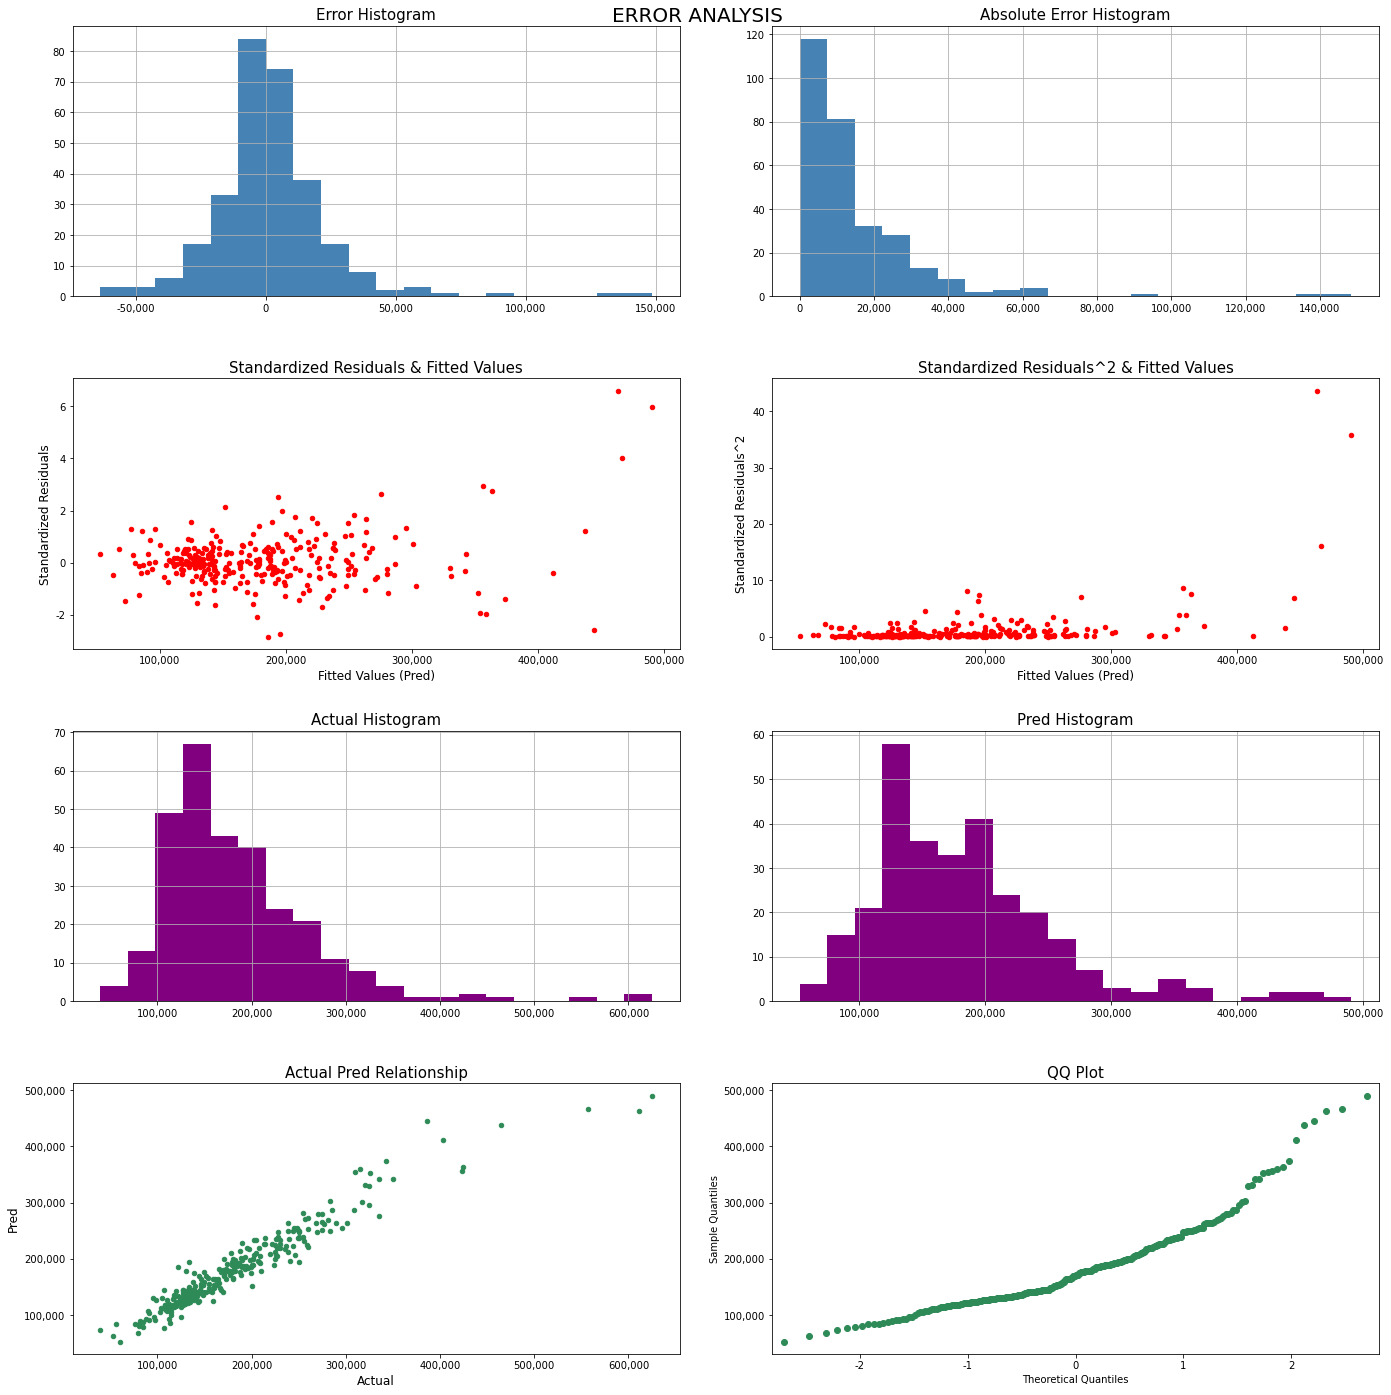

In [47]:
fig, axes = plt.subplots(4, 2, figsize = (20,20))
for axi in axes.flat:
    axi.ticklabel_format(style="sci", axis="y", scilimits=(0,10))
    axi.ticklabel_format(style="sci", axis="x", scilimits=(0,10))
    axi.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    axi.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
res.hist("Error", ax = axes[0, 0], color = "steelblue", bins = 20)
res.hist("AbsoluteError", ax = axes[0,1], color = "steelblue", bins = 20)
sr = res.copy()
sr["StandardizedR"] = (sr.Error / sr.Error.std())
sr["StandardizedR2"] = ((sr.Error / sr.Error.std())**2)
sr.plot.scatter(x = "Pred",y = "StandardizedR", color = "red", ax = axes[1,0])
sr.plot.scatter(x = "Pred",y = "StandardizedR2", color = "red", ax = axes[1,1])
res.Actual.hist(ax = axes[2, 0], color = "purple", bins = 20)
res.Pred.hist(ax = axes[2, 1], color = "purple", bins = 20)
res.plot.scatter(x = "Actual",y = "Pred", color = "seagreen", ax = axes[3,0]);
# QQ Plot
import statsmodels.api as sm
import pylab
sm.qqplot(sr.Pred, ax = axes[3,1], c = "seagreen")
plt.suptitle("ERROR ANALYSIS", fontsize = 20)
axes[0,0].set_title("Error Histogram", fontsize = 15)
axes[0,1].set_title("Absolute Error Histogram", fontsize = 15)
axes[1,0].set_title("Standardized Residuals & Fitted Values", fontsize = 15)
axes[1,1].set_title("Standardized Residuals^2 & Fitted Values", fontsize = 15)
axes[2,0].set_title("Actual Histogram", fontsize = 15)
axes[2,1].set_title("Pred Histogram", fontsize = 15);
axes[3,0].set_title("Actual Pred Relationship", fontsize = 15);
axes[3,1].set_title("QQ Plot", fontsize = 15);
axes[1,0].set_xlabel("Fitted Values (Pred)", fontsize = 12)
axes[1,1].set_xlabel("Fitted Values (Pred)", fontsize = 12)
axes[3,0].set_xlabel("Actual", fontsize = 12)
axes[1,0].set_ylabel("Standardized Residuals", fontsize = 12)
axes[1,1].set_ylabel("Standardized Residuals^2", fontsize = 12)
axes[3,0].set_ylabel("Pred", fontsize = 12)
fig.tight_layout(pad=3.0)
plt.savefig("errors.png")
plt.show()

<a id='rs'></a>
<h1 style="color:firebrick" >15. RANDOMIZED SEARCH CV</h1>

In [48]:
params = {
    # Training 
    'learning_rate': [0.1, 0.09, 0.08, 0.07, 0.05],
    # Tree
    'max_depth': [-1] + np.arange(5, 33, 1),
    # Deal with Over-fitting
    'num_leaves':np.arange(20, 81, 1),
    'n_estimators':[100, 500, 1000, 3000, 4000, 5000, 10000, 15000], 
    'max_bin':np.arange(240, 301, 5), # Default 255
    'min_data_in_leaf':np.arange(15, 31, 1), # Default 20
    #"feature_fraction_seed":np.arange(2, 100, 1),
    #"feature_fraction":np.arange(0.1, 1.01, 0.01),#[0.4, 0.5, 0.6, 0.7, 0.8, 0.8, 1], #0.41,# Default: 1 
    #"bagging_freq":[0], # Default: 0 | Note: to enable bagging, bagging_freq should be set to a non zero value as well
    #"bagging_fraction":[1], # Default: 1 
    #"min_sum_hessian_in_leaf":[1e-2,1e-3, 1e-4, 1e-5, 1e-6], # Default: 1e-3 
    # Regularization
    # - Try lambda_l1, lambda_l2 and min_gain_to_split for regularization
    # "lambda_l1":np.arange(0.0, 1.1, 0.1),
    "lambda_l2":np.arange(0.0, 1.1, 0.1),
    "min_gain_to_split ": np.arange(0, 11, 1)  # Default: 0
}


reg = lgb.LGBMRegressor(
    random_state=46, objective = "rmse", metric = "rmse"
)

from sklearn.model_selection import RandomizedSearchCV
rs = RandomizedSearchCV(reg, params, random_state=46, cv = 5, scoring = "neg_mean_squared_error")
rs_lgbm = rs.fit(X_train, y_train,
                 eval_set=[(X_train, y_train),(X_test, y_test)],
                 eval_metric = ["rmse", "mae"],
                 eval_names=["Train", "Valid"],
                 early_stopping_rounds=30,
                 verbose=0,
                 categorical_feature='auto')

print(rs_lgbm.best_params_)

{'num_leaves': 73, 'n_estimators': 10000, 'min_gain_to_split ': 9, 'min_data_in_leaf': 15, 'max_depth': 4, 'max_bin': 250, 'learning_rate': 0.07, 'lambda_l2': 0.5}


In [49]:
print("# MODEL RESULTS \n Train RMSE: {:,.2f} \n Valid RMSE: {:,.2f} \n\n Train MAE: {:,.2f} \n Valid MAE: {:,.2f} \n\n Train RMSLE: {:,.5f} \n Valid RMSLE: {:,.5f} \n\n Train R2: {:,.2f} \n Valid R2: {:,.2f}".format(
  mean_squared_error(y_train, rs_lgbm.predict(X_train), squared=False),
  mean_squared_error(y_test, rs_lgbm.predict(X_test), squared=False),
  mean_absolute_error(y_train, rs_lgbm.predict(X_train)),
  mean_absolute_error(y_test, rs_lgbm.predict(X_test)),
  np.sqrt(mean_squared_log_error(y_train, rs_lgbm.predict(X_train))),
  np.sqrt(mean_squared_log_error(y_test, rs_lgbm.predict(X_test))),
  r2_score(y_train, rs_lgbm.predict(X_train)),
  r2_score(y_test, rs_lgbm.predict(X_test))
  ))

# MODEL RESULTS 
 Train RMSE: 15,332.03 
 Valid RMSE: 23,178.89 

 Train MAE: 10,114.63 
 Valid MAE: 14,728.33 

 Train RMSLE: 0.09018 
 Valid RMSLE: 0.11191 

 Train R2: 0.96 
 Valid R2: 0.92


<a id='final'></a>
<h1 style="color:firebrick" >16. FINAL MODEL & SUBMISSION</h1>

In [50]:
train_model = df[df.Id.isin(train.Id)].drop(df.select_dtypes(object).columns, axis = 1)
test_model = df[df.Id.isin(test.Id)].drop(df.select_dtypes(object).columns, axis = 1)
test_model.drop("SalePrice", axis = 1, inplace = True)


X = train_model.drop(['SalePrice', "Id"], axis=1)
y = train_model[["SalePrice"]]


final = lgb.LGBMRegressor(
    random_state=46,
    **rs_lgbm.best_params_
)

final.fit(X,y, 
        eval_set=[(X,y)],
        eval_metric = ["rmse", "mae"],
        eval_names=["Train"],
        # early_stopping_rounds=10,
        verbose=1000,
        categorical_feature='auto')
        
        
        
print("# MODEL RESULTS \n Train RMSE: {:,.2f}  \n\n Train MAE: {:,.2f}  \n\n Train RMSLE: {:,.5f} \n\n Train R2: {:,.2f}".format(
  mean_squared_error(y, final.predict(X), squared=False),
  mean_absolute_error(y, final.predict(X)),
  np.sqrt(mean_squared_log_error(y, final.predict(X))),
  r2_score(y, final.predict(X))
  ))


# Submission
submission = pd.DataFrame({"Id": test_model.Id, "SalePrice":final.predict(test_model.drop("Id", axis = 1))})
submission.to_csv("submission.csv", index = None)


[1000]	Train's rmse: 3285.54	Train's l1: 2301.53	Train's l2: 1.07948e+07
[2000]	Train's rmse: 1072.5	Train's l1: 699.326	Train's l2: 1.15025e+06
[3000]	Train's rmse: 439.442	Train's l1: 255.07	Train's l2: 193109
[4000]	Train's rmse: 260.84	Train's l1: 127.256	Train's l2: 68037.7
[5000]	Train's rmse: 189.566	Train's l1: 74.0365	Train's l2: 35935.3
[6000]	Train's rmse: 159.817	Train's l1: 45.6769	Train's l2: 25541.5
[7000]	Train's rmse: 147.613	Train's l1: 30.4096	Train's l2: 21789.7
[8000]	Train's rmse: 142.209	Train's l1: 20.3806	Train's l2: 20223.3
[9000]	Train's rmse: 140.096	Train's l1: 14.3157	Train's l2: 19626.9
[10000]	Train's rmse: 139.299	Train's l1: 10.8468	Train's l2: 19404.2
# MODEL RESULTS 
 Train RMSE: 139.30  

 Train MAE: 10.85  

 Train RMSLE: 0.00104 

 Train R2: 1.00
